In [1]:
from dataset import *
from evaluate import *
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


 
- Arrowhead Beach: 36.236102, -76.695387 (Planet 4)

- Cannon's Ferry: 36.271557, -76.672967 (Planet 6)

- Rocky Hock: 36.183649, -76.719210 (Planet 3)

- Chowan River Bridge: 36.055233, -76.686425 (Planet 5)

- Point Comfort: 36.169458, -76.751827 (Planet 1)

- Mt. Gould : 36.123866, -76.742630 (Planet 2)

In [2]:
class Weak_Supervision_Dataset():    
    def __init__(self, img_dir,lbl_dir, lat, lon, transforms=None):
        
        self.transforms = transforms
        markers = set()
        self.planet_paths = []
        self.sentinel_paths = {}
        self.cicyano_paths ={}
        self.img_dir = img_dir
        self.lbl_dir = lbl_dir
        self.lat = lat,
        self.lon = lon

        for file in sorted(listdir(self.img_dir)):
            parts = file.split('_')[0]  
            if parts not in markers:
                self.planet_paths.append(os.path.join(self.img_dir, file))
                markers.add(parts)

        for folder in sorted(os.listdir(self.lbl_dir)):
            if folder not in [".DS_Store", ".ipynb_checkpoints"]:
                folder_path = os.path.join(self.lbl_dir, folder)
                for file in sorted(os.listdir(folder_path)):
                    if file.endswith('.tif'):
                        parts = file.split('.')
                        name = parts[-3] 
                        marker = parts[1][:4] + parts[2]  
                        if marker in markers and name == 'CIcyano':
                            if marker not in self.cicyano_paths: 
                                self.cicyano_paths[marker] = os.path.join(folder_path, file)
                                
        for folder in sorted(os.listdir(self.lbl_dir)):
            if folder not in [".DS_Store", ".ipynb_checkpoints"]:
                folder_path = os.path.join(self.lbl_dir, folder)
                for file in sorted(os.listdir(folder_path)):
                    if file.endswith('.tif'):
                        parts = file.split('.')
                        name = parts[-3] 
                        marker = parts[1][:4] + parts[2]  
                        if marker in markers and name == 'truecolor':
                            if marker not in self.sentinel_paths: 
                                self.sentinel_paths[marker] = os.path.join(folder_path, file)
                                

        self.matches = {}
        for img_path in self.planet_paths:
            img_marker = img_path.split('/')[-1].split('_')[0]  
            if img_marker in markers:
                self.matches[img_marker] = {
                    'planet': img_path,
                    'cicyano': self.cicyano_paths.get(img_marker, None),
                    'sentinel': self.sentinel_paths.get(img_marker,None)
                }
        
        self.matches = {marker: paths for marker, paths in self.matches.items() if paths['cicyano'] is not None}
        self.keys = list(self.matches.keys())

    def __len__(self): return len(self.matches)
    
    def __getitem__(self, idx):
        marker = self.keys[idx]
        
        #planet image handling 
        with rio.open(self.matches[marker]['planet']) as rds:
            data = rds.read([1,2,3])
            planet_data = np.array(data) #shape (3,600,600)
            planet_data = np.moveaxis(planet_data, 0,2) #to match axis order of NASA data
            
        with rio.open(self.matches[marker]['sentinel']) as rds:
            data = rds.read([1,2,3])
            unalt = data
            crop_size = 2.5

            transformer = Transformer.from_crs("EPSG:4326", rds.crs, always_xy=True)
            xx, yy = transformer.transform(self.lon, self.lat)
            row, col = rds.index(xx, yy)

            row_start = max(row - crop_size, 0)
            row_end = min(row + crop_size, rds.height)
            col_start = max(col - crop_size, 0)
            col_end = min(col + crop_size, rds.width)
     
            window = Window.from_slices((row_start, row_end), (col_start, col_end))
            data = rds.read(window=window)
            data = np.moveaxis(data, 0, 2)  
            sentinel_data = np.array(data)

        #label handling
        with rio.open(self.matches[marker]['cicyano']) as rds:
            data = rds.read()
            crop_size = 2.5
            transformer = Transformer.from_crs("EPSG:4326", rds.crs, always_xy=True)
            xx, yy = transformer.transform(self.lon, self.lat)
            row, col = rds.index(xx, yy)

            row_start = max(row - crop_size, 0)
            row_end = min(row + crop_size, rds.height)
            col_start = max(col - crop_size, 0)
            col_end = min(col + crop_size, rds.width)

            window = Window.from_slices((row_start, row_end), (col_start, col_end))
            data = rds.read(window=window)
            data = np.moveaxis(data, 0, 2)  
            lbl_arr = np.array(data)

            fpt_avg = np.where((31 <= lbl_arr) & (lbl_arr<= 249), lbl_arr, 0) #bloom pixel avg only
            fpt_avg = fpt_avg[fpt_avg !=0]
            mean_value = fpt_avg.mean() if fpt_avg.size > 0 else 0

            #label with land (2), cloud (3), bloom (1), else (0)
            fptdata = np.where(lbl_arr == 252, 2, np.where(lbl_arr == 253, 3, np.where((31 <= lbl_arr) & (lbl_arr<= 249), 1, 0)))

            if 31 <= mean_value <= 249:
                class_lbl = 1
            else: class_lbl = 0
                

        sample ={'planet': planet_data,
                  'planet_file': self.matches[marker]['planet'],
                  'sentinel': sentinel_data,
                  'sentinel_file': self.matches[marker]['sentinel'],
                  'cicyano': fptdata,
                  'cicyano_file': self.matches[marker]['cicyano'],
                  'ci_avg': round(mean_value),
                  'class_label': class_lbl
                 }

        if self.transforms:
            sample = self.transforms(sample)

        return sample
        
    def display(self, idx):

        sample = self[idx]
        planet = sample['planet']
        sentinel = sample['sentinel']
        cicyano = sample['cicyano']
        label = sample['ci_avg']

        class_label = sample['class_label']
        inf = sample['planet_file'].split('/')

        d=inf[-1].split('_')[0]
        d = d[4:6]+'-'+d[6:]+'-'+d[:4]
        p = inf[-2]
        
        colors = ['black', 'seagreen', 'yellow', 'grey']  # Set your desired colors for each class here
        cmap = ListedColormap(colors)
        boundaries = [0, 1, 2, 3, 4]  # Each boundary represents a class (0, 1, 2, 3)
        norm = BoundaryNorm(boundaries, cmap.N)
        fig,(ax1, ax2,ax3) = plt.subplots(1,3, figsize=(15,15))
        fig.suptitle(f' {d} at {p}',y=0.68)
        
        ax1.imshow(planet, zorder=1)
        ax1.axis('off')
        ax1.set_title(f'Planet')
#         grid_color = 'white'
#         linewidth = 0.1
#         for i in range(1, 5):
#             # Draw vertical lines
#             ax1.vlines(x=planet.shape[1] * i / 5, ymin=0, ymax=planet.shape[0], color=grid_color, linewidth=linewidth)
#             # Draw horizontal lines
#             ax1.hlines(y=planet.shape[0] * i / 5, xmin=0, xmax=planet.shape[1], color=grid_color, linewidth=linewidth)

 
        ax2.imshow(cicyano, cmap=cmap,norm=norm)
        ax2.axis('off')
        ax2.set_title(f'Class Label: {class_label}')

        ax3.imshow(sentinel)
        ax3.axis('off')
        ax3.set_title(f'Sentinel Avg Label: {round(label)}')
        plt.show()

        return fig


def create_dataset(*args, apply_transforms=True, **kwargs):
    if apply_transforms:
        data_transforms = transforms.Compose([
#             FlipsAndTricks(),
#             CropAndChop(),
#             Normalize(),
            ToTensor(),])
    else: data_transforms = None

    data = Weak_Supervision_Dataset(*args, **kwargs, transforms=data_transforms)
    return data

In [3]:
lbl_dir = '/datacommons/carlsonlab/srs108/blooms/all_data'

img_dir = '/datacommons/carlsonlab/srs108/crops/arrowhead_beach/'
lat,lon = 36.236724, -76.698134
a=create_dataset(img_dir, lbl_dir, lat, lon, apply_transforms=True)

img_dir = '/datacommons/carlsonlab/srs108/crops/cannons_ferry/'
lat,lon = 36.272006, -76.675842
b=create_dataset(img_dir, lbl_dir, lat, lon, apply_transforms=True)

img_dir = '/datacommons/carlsonlab/srs108/crops/chowan_river/'
lat,lon = 36.055163, -76.690760
c=create_dataset(img_dir, lbl_dir, lat, lon, apply_transforms=True)

img_dir = '/datacommons/carlsonlab/srs108/crops/mt_gould/'
lat,lon = 36.125495, -76.740141
d=create_dataset(img_dir, lbl_dir, lat, lon, apply_transforms=True)

img_dir = '/datacommons/carlsonlab/srs108/crops/point_comfort/'
lat,lon = 36.169908, -76.745905
e=create_dataset(img_dir, lbl_dir, lat, lon, apply_transforms=True)

img_dir = '/datacommons/carlsonlab/srs108/crops/rocky_hock_lane/'
lat,lon = 36.184133, -76.722858
f=create_dataset(img_dir, lbl_dir, lat, lon, apply_transforms=True)
all_chowan = torch.utils.data.ConcatDataset([a,b,c,d,e,f])

val_ratio, test_ratio = 0.25, 0.25
dataset_size = len(all_chowan)
indices = list(range(dataset_size))
batch_size = 16

train_indices, temp_indices = train_test_split(indices, test_size=(val_ratio + test_ratio), shuffle=True)
val_indices, test_indices = train_test_split(temp_indices, test_size=test_ratio/(val_ratio + test_ratio))
train_dataset = Subset(all_chowan, train_indices)
val_dataset = Subset(all_chowan, val_indices)
test_dataset = Subset(all_chowan, test_indices)

In [4]:
len(all_chowan)

4807

In [4]:
# a[8]['planet_file'].split('/')[-1][:8]

In [1]:
# counts = 0
# for i in range(len(a)):
#     if a[i]['class_label'] == 1:
#         x = a.display(i)
#         counts +=1

In [6]:
# all_labels = [train_dataset[i]['class_label'] for i in tqdm(range(len(train_dataset)),position=0, leave=True)]
# class_counts = np.bincount(all_labels)
# class_weights = 1.0 / class_counts 
# sample_weights = [class_weights[label] for label in all_labels]
# sample_weights = torch.tensor(sample_weights, dtype=torch.float)
# print(class_counts)

In [7]:
# torch.save((class_counts, class_weights, sample_weights), 'binary_weights.pth')
class_counts, class_weights, sample_weights = torch.load('binary_weights.pth')

In [8]:
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,drop_last = True)

In [9]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.resnet_pretrained = resnet50(pretrained=True)
        self.resnet_pretrained.conv1 = nn.Conv2d(3, 64, kernel_size=(3, 3),
                              stride=(2, 2),padding=(3, 3), bias=False)
        
        self.fc1 = nn.Linear(self.resnet_pretrained.fc.out_features, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 1)  # output size changed to 2
        self.dropout = nn.Dropout(p=0.35)
    def forward(self, image):
        img_features = self.resnet_pretrained(image)
        img_features = torch.flatten(img_features, 1)
        img_features = self.fc1(img_features)
        x = self.relu(img_features)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc3(x)
        return x


In [10]:
def test(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0
    running_acc = 0

    with torch.no_grad():
        for i, batch in tqdm(enumerate(dataloader)):
            x = batch['planet'].float().to(device)
            y = batch['class_label'].float().to(device)
            output = model(torch.permute(x, (0,3,1,2))).squeeze(dim=1)
                    
            output_binary = np.zeros(output.shape)
            output_binary[output.cpu().detach().numpy() >= 0] = 1
#             print(output_binary)
            loss = criterion(output,y)
            running_loss += loss.item()
            
            #accuracy
            label = y.cpu().detach().numpy()
            acc = accuracy_score(label,output_binary)
            running_acc += acc

            torch.cuda.empty_cache()
        return running_loss/len(dataloader), running_acc/len(dataloader)
            

In [11]:
def train(model, dataloader, criterion, opt, epoch, device):
    running_acc = 0
    running_loss = 0
    model.train()

    for i, batch in tqdm(enumerate(dataloader)):
        x = batch['planet'].float().to(device)
        y = batch['class_label'].float().to(device) 
        output = model(torch.permute(x, (0,3,1,2))).squeeze(dim=1) #outputs logits (outputs before activation)
        
        output_binary = np.zeros(output.shape)
        output_binary[output.cpu().detach().numpy() >= 0] = 1 #if logit is greater than 0, classify as bloom
        #loss
        loss = criterion(output,y) #BCEwL
        running_loss += loss.item()
        
        #accuracy
        label = y.cpu().detach().numpy()
        acc = accuracy_score(label,output_binary)
        running_acc += acc

        opt.zero_grad()
        loss.backward()
        opt.step()
        torch.cuda.empty_cache()
        
    return running_loss/len(dataloader), running_acc/len(dataloader)

In [12]:
def main(model, epochs):
    opt                        = optim.Adam(model.parameters(), lr=1e-5)#, momentum=0.9)
    criterion                  = nn.BCEWithLogitsLoss().to(device)  
    best_loss                 = 1e6
    patience                   = np.ceil(0.1*epochs)
    trigger_times              = 0
    history = {'epoch':[],'train_loss': [], 'val_loss':[], 'train_acc': [], 'val_acc':[]}

    for epoch in range(1, epochs+1):

        train_loss, train_acc = train(model,  train_loader, criterion, opt, epoch, device)
        val_loss, val_acc = test(model, val_loader, criterion, device)


        if val_loss < best_loss:
            trigger_times = 0
            best_loss = val_loss
            best_model_weights = model.state_dict()
            torch.save(model.state_dict(), 'x.pt')

        else:
            trigger_times += 1
            if trigger_times == patience:
                print(f"Early stopping on epoch {epoch} - patience reached")
                torch.save(model.state_dict(), 'final_weights.pt')
                break

        print(f'Epoch {epoch}\n\tCurrent train/val Loss: {round(train_loss, 5)}/{round(val_loss, 5)}\n\tCurrent train/val Accuracy: {round(train_acc,5)}/{round(val_acc,5)}')

        if trigger_times != 0:
            print(f'\tCurrent Triggers: {trigger_times}')

        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        df = pd.DataFrame(history)
        df.to_csv('x.csv', index=False)

In [20]:
model = CNN().to(device)
# model.load_state_dict(torch.load('/datacommons/carlsonlab/srs108/weak/binary/binary.pt'))
main(epochs=200, model=model)
# %time

151it [02:25,  1.04it/s]
76it [00:45,  1.68it/s]
0it [00:00, ?it/s]

Epoch 1
	Current train/val Loss: 0.6833/0.67321
	Current train/val Accuracy: 0.56567/0.51151


0it [00:01, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 46.00 MiB. GPU 0 has a total capacty of 10.57 GiB of which 33.12 MiB is free. Including non-PyTorch memory, this process has 10.54 GiB memory in use. Of the allocated memory 9.73 GiB is allocated by PyTorch, and 613.30 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

# Post Run
## Plots

In [13]:
df = pd.read_csv('/datacommons/carlsonlab/srs108/weak/binary/x.csv')

In [14]:
trl = min(df['train_loss'])
vl = min(df['val_loss'])
tra = max(df['train_acc'])
va = max(df['val_acc'])

In [15]:
print(f'Training Accuracy: {tra}\nValidation Accuracy: {va}\nTraining Loss: {trl}\nValidation Loss: {vl}')

Training Accuracy: 0.7547065337763011
Validation Accuracy: 0.6895695364238411
Training Loss: 0.4904424326859439
Validation Loss: 0.553038806611339


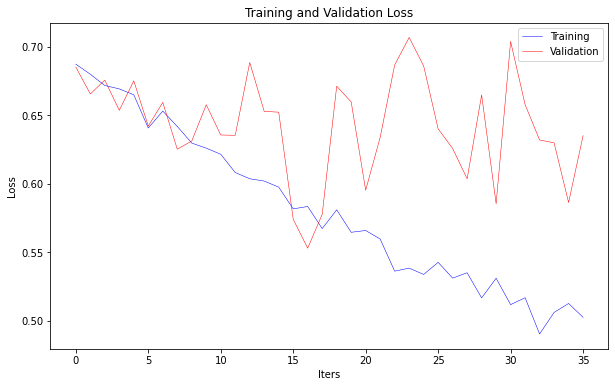

In [16]:
train_val_loss(df['train_loss'], df['val_loss'], len(df['epoch']), save=True)

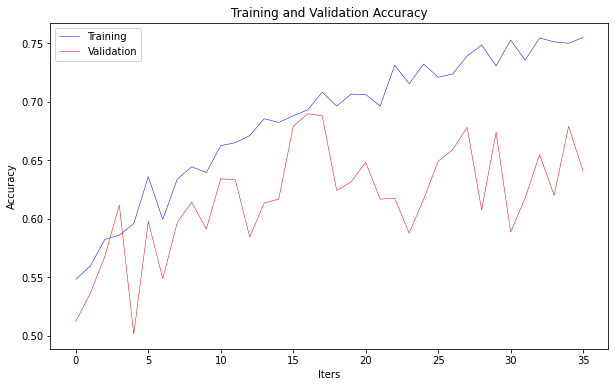

In [17]:
train_val_acc(df['train_acc'], df['val_acc'], len(df['epoch']), save=True)

## Testing

In [18]:
model = CNN().to(device)
model.load_state_dict(torch.load('/datacommons/carlsonlab/srs108/weak/binary/x.pt'))
criterion = nn.BCEWithLogitsLoss().to(device)  

<All keys matched successfully>

In [2]:
model.eval()
running_loss = 0
running_acc = 0

all_labels_for_auc = []
all_outputs_for_auc = []

all_binary_for_cm = []
all_labels_for_cm = []
all_outputs_for_cm = []

with torch.no_grad():
    for i, batch in tqdm(enumerate(test_loader)):
        x = batch['planet'].float().to(device)
        y = batch['class_label'].float().to(device) 
        c = batch['ci_avg'].to(device)
        output = model(torch.permute(x, (0,3,1,2))).squeeze(dim=1)

        output_binary = np.zeros(output.shape)
        output_binary[output.cpu().detach().numpy() >= 0] = 1

        loss = criterion(output, y)
        running_loss += loss.item()

        all_labels_for_auc.append(y.cpu().detach().numpy())
        all_outputs_for_auc.append(output.cpu().detach().numpy())
        
        all_labels_for_cm.extend(y.cpu().detach().numpy().tolist())  # Append only values
        all_outputs_for_cm.extend(output.cpu().detach().numpy().tolist())  # Append only values
        all_binary_for_cm.extend(output_binary.tolist()) 

        # accuracy
        label = y.cpu().detach().numpy()
        acc = accuracy_score(label, output_binary)
        running_acc += acc
       
#         bloom_image_plotting(batch, output_binary,y,c)
        torch.cuda.empty_cache()
# AUC
all_labels_for_auc = np.concatenate(all_labels_for_auc)
all_outputs_for_auc = np.concatenate(all_outputs_for_auc)
auc = roc_auc_score(all_labels_for_auc, all_outputs_for_auc)
fpr, tpr, thresholds = roc_curve(all_labels_for_auc, all_outputs_for_auc)

0.6819031706249752
Testing Accuracy 0.7008333333333333
Testing Loss 0.5671131249268849


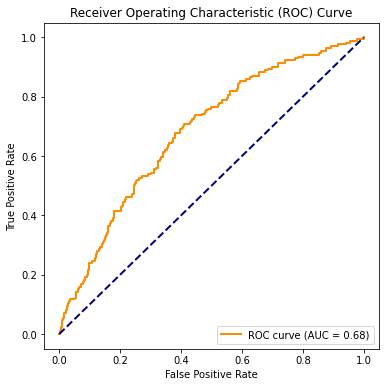

In [23]:
# print(auc)

# print('Testing Accuracy',running_acc/len(test_loader))
# print('Testing Loss',running_loss/len(test_loader))

# plot_roc_curve(fpr, tpr, auc, save=True)

In [30]:
cm = confusion_matrix(all_labels_for_cm, all_binary_for_cm)

plt.figure(figsize=(6, 4))  # Adjust the figure size as needed
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g',
            xticklabels=['no bloom', 'bloom'],
            yticklabels=['no bloom', 'bloom'])

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight',facecolor='white')  # Adjust dpi and bbox_inches as needed
plt.close() 